# Natural Language Processing with Disaster Tweets

**Task**  
Predict which Tweets are about real disasters and which ones are not.

**Columns:**
- ID
- Keyword
- Location
- Text
- Target

**Models**  
I used a baseline Naive Bayes model and a Neural Network archiecture using DistilBERT as the embedding layer with a LSTM and Dense layers following. I used huggingface's transformers library and tensorflow for the deep learning model and scikit-learn for the naive bayes model. I also used GPU acceleration through a GTX 1060 (6GB) for training the neural network. 

**Link to data:**  
https://www.kaggle.com/competitions/nlp-getting-started/data

<hr>

**Imports**

In [1]:
import os
import re
import string
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from transformers import logging
from transformers import DistilBertTokenizer, TFDistilBertModel, DistilBertConfig
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

logging.set_verbosity_error() # Hidding Huggingface Warnings
warnings.filterwarnings("ignore")

/usr/local/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2022-05-29 17:44:24.423763: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Enabling GPU

In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

In [3]:
plt.style.use('ggplot')

### Loading Data

In [4]:
train_df = pd.read_csv('dataset/train.csv', encoding = "UTF-8", encoding_errors = 'ignore')
test_df = pd.read_csv('dataset/test.csv', encoding = "UTF-8", encoding_errors = 'ignore')

*Dropping any duplicates data*

In [5]:
train_df.drop_duplicates(inplace = True) # "inplace = True" will manipulate on original dataframe; otherwise create a new one
test_df.drop_duplicates(inplace = True)

In [6]:
train_df.isna().sum() # Count the missing value

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

In [7]:
test_df.isna().sum()

id             0
keyword       26
location    1105
text           0
dtype: int64

Because a missing location is not as important as a missing tweet or sentiment, I will not remove those entires.

In [8]:
print(f"There are {train_df.shape[0]} data in the training dataset")
train_df.head()

There are 7613 data in the training dataset


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [9]:
print(f"There are {test_df.shape[0]} data in the testing dataset")
test_df.head()

There are 3263 data in the testing dataset


,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


Text(0, 0.5, 'Counts')

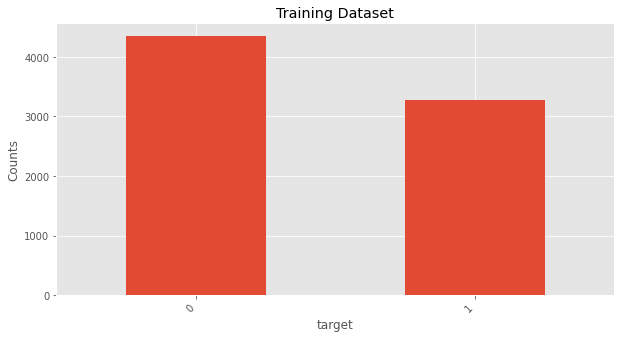

In [10]:
reorder = [0, 1]

fig, axes = plt.subplots(figsize = (10, 5))

train_df.value_counts('target').reindex(index = reorder).plot(kind = 'bar', ax = axes)
plt.sca(axes) # Set Axes
plt.xticks(rotation = 45, horizontalalignment = 'right')
plt.title('Training Dataset')
plt.ylabel('Counts')

It looks like the training and testsing datasets are not balanced across all categories.

*To count how many words in the longest sentence*

In [11]:
max_words = []
for row in train_df['text']:
    max_words.append(len(row.split()))
print(f"The max word count is {np.asarray(max_words).max()}")

The max word count is 31


**Getting rid of the URL's in the tweets**

In [12]:
test_str = test_df['text'][0]
print(test_str)

def remove_https(row):
    return re.sub(r'http\S+', '', row) # Replace string with Regular expression operation

remove_https(test_str)

Just happened a terrible car crash


'Just happened a terrible car crash'

*Apply to whole datasets*

In [13]:
train_df['text_no_URL'] = train_df['text'].apply(remove_https)
test_df['text_no_URL'] = test_df['text'].apply(remove_https)

**Splitting the data**

I will take 10% of the training data as validation data

In [14]:
# Get the number training samples
train_num = int(train_df.shape[0] * 0.9)

x_train = train_df['text_no_URL'][:train_num]
y_train = train_df['target'][:train_num]
x_val = train_df['text_no_URL'][train_num:]
y_val = train_df['target'][train_num:]

# Check the total is right
assert(len(x_train) + len(x_val) == train_df.shape[0]) # When the equation is false, system will alert an error

print(f"{len(x_train)} training examples\n{len(x_val)} validation examples")

6851 training examples
762 validation examples


In [15]:
x_test = test_df['text_no_URL']
print(f"{len(x_test)} testing examples")

3263 testing examples


## Naive Bayes (Baseline Model)

Pre-processing by:  
- remove punctuations (except #)
- lowercase all words
- removing stopwords
- stemming words

*Note: I will not remove the **#** symbol because it is a predominant part of what makes tweets unique*

Stopwords are common words in natural language, and they have a very little meaning.

In [16]:
stop_words = set(stopwords.words('english')) # Create a set including english stopwords
porter = PorterStemmer()

# Remove all puncutation and stopwords
def clean_responses(text):
    # Remove all puncutation
    string.punctuation = string.punctuation.replace('#','') # We keep '#' in our training
    for punctuation in string.punctuation:
        text = text.replace(punctuation, '')
    
    # Lowercase
    text = text.lower() # Make every letter is lowercase
    
    # Removing stopwords
    filtered_words = []
    for word in text.split():
        if word not in stop_words:
            filtered_words.append(word)
            
    # Stemming words(delete 'ing' and other ones, only keeping stem)
    stemmed = [porter.stem(word) for word in filtered_words]
                
    return ' '.join(stemmed)

In [17]:
X_train_NB = x_train.apply(clean_responses)
y_train_NB = y_train
X_val_NB = x_val.apply(clean_responses)
y_val_NB = y_val

In [18]:
model = make_pipeline(TfidfVectorizer(), MultinomialNB()) # Use TfidfVectorize() to convert word to vector, and MultinomialNB() to classify
model.fit(X_train_NB, y_train_NB)

# Make predictions
y_hat = model.predict(X_val_NB)

**Results**

Accuracy: 0.7939632545931758


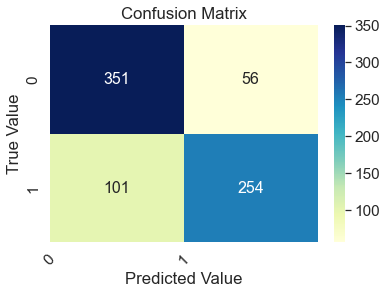

In [19]:
print("Accuracy:", accuracy_score(y_val_NB, y_hat))
labels_2 = [0, 1] 

def print_cf1(y_val, y_hat):
    cm = confusion_matrix(y_val, y_hat)
    sns.set(font_scale = 1.4, color_codes = True, palette = "deep")
    sns.heatmap(pd.DataFrame(cm, index = labels_2, columns = [0,1]), 
                annot = True,
                annot_kws = {"size":16},
                fmt = "d",
                cmap = "YlGnBu")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Value")
    plt.xticks([0,1], labels_2, rotation = 45)
    plt.ylabel("True Value")
    plt.show()
    
print_cf1(y_val_NB, y_hat)

In [21]:
print(classification_report(y_val_NB, y_hat, target_names = ['0', '1'])) #、

              precision    recall  f1-score   support

           0       0.78      0.86      0.82       407
           1       0.82      0.72      0.76       355

    accuracy                           0.79       762
   macro avg       0.80      0.79      0.79       762
weighted avg       0.80      0.79      0.79       762



## DistilBERT

**DistilBERT Model**

https://huggingface.co/distilbert-base-uncased

In [22]:
MODEL_NAME = 'distilbert-base-cased' # 'cased' will distinguish 'a' and 'A'; 'uncased' won't # 、

**Tokenize the Inputs** 

In [23]:
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME) # Loading the tokenizer, which do punctuation splitting and wordpiece

Downloading: 100%|██████████| 208k/208k [00:00<00:00, 358kB/s]  
Downloading: 100%|██████████| 29.0/29.0 [00:00<00:00, 9.81kB/s]
Downloading: 100%|██████████| 411/411 [00:00<00:00, 147kB/s]


*Finding the max token sequence in the training set*

In [24]:
max_val = 0
for sent in (x_train.tolist() + x_train.tolist() + x_val.tolist()): # 、
    try:
        sent_tok_len = len(tokenizer.tokenize(sent))
        max_val = sent_tok_len if (sent_tok_len > max_val) else max_val
    except:
        pass
    
print(f"The maximum amount of tokens in the dataset is {max_val}")

The maximum amount of tokens in the dataset is 104


I will set the max length and input for the deep learning model to 106  
*(Max token length + 2 for [CLS] and [SEP])*

In [25]:
MAX_LENGTH = 106

tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME,  
                                                add_special_tokens = True, # Add a dictionary of special tokens, like CLS, EOS...
                                                max_length = MAX_LENGTH, 
                                                pad_to_max_length = True) # Will padding(add space) until max length

def tokenize(sentences, tokenizer):
    input_ids, input_masks, input_segments = [], [], []
    for sentence in tqdm(sentences): # tqdm is progress bar
        inputs = tokenizer.encode_plus(sentence, # Return all coding info, including word ids, token type ids, doing self attention to which words(attention_mask)
                                       add_special_tokens = True, 
                                       max_length = MAX_LENGTH, 
                                       pad_to_max_length = True, 
                                       return_attention_mask = True, 
                                       return_token_type_ids = True, # Token type ids are a binary mask identifying the different sequences in the model.
                                       truncation = True) # Truncate to a max length sequence
        input_ids.append(inputs['input_ids'])
        input_masks.append(inputs['attention_mask'])
        input_segments.append(inputs['token_type_ids']) # 、
        
    return np.asarray(input_ids, dtype = 'int32'), np.asarray(input_masks, dtype = 'int32')

In [26]:
X_train = tokenize(x_train, tokenizer)
X_test = tokenize(x_test, tokenizer)
X_val = tokenize(x_val, tokenizer)

100%|██████████| 762/762 [00:00<00:00, 2390.91it/s]


**Looking at entry**

In [28]:
index_num = 5

print(train_df.loc[index_num]['target'], '\n')

print(x_train[index_num], '\n')

temp_tokens = tokenizer.tokenize(x_train[index_num])
temp_ids = tokenizer.encode(x_train[index_num])

print('ID\'s', 'Input Tokens', sep = '\t')
for i in range(len(temp_ids)):
    if i == 0:
        print(temp_ids[i], '[CLS]', sep = '\t')
        continue
    if i == len(temp_ids)-1:
        print(temp_ids[i], '[SEP]', sep = '\t')
        break
    print(temp_ids[i], temp_tokens[i-1], sep = '\t') #、

1 

#RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #CAfire #wildfires 

ID's	Input Tokens
101	[CLS]
108	#
9376	Rocky
2271	##F
5817	##ire
3725	Up
9216	##date
134	=
135	>
1756	California
145	H
17953	##wy
119	.
1406	20
1804	closed
1107	in
1241	both
7768	directions
1496	due
1106	to
2161	Lake
1391	County
1783	fire
118	-
108	#
8784	CA
7117	##fire
108	#
4098	wild
20259	##fires
102	[SEP]


### Creating the model

Hidden-states of the model at the output of each layer plus the initial embedding outputs.

Attentions weights after the attention softmax, used to compute the weighted average in the self-attention heads.

In [29]:
config = DistilBertConfig.from_pretrained(MODEL_NAME, output_hidden_states = True, output_attentions = True)
DistilBERT = TFDistilBertModel.from_pretrained(MODEL_NAME, config = config)

input_ids_in = tf.keras.layers.Input(shape = (MAX_LENGTH,), name = 'input_token', dtype = 'int32')
input_masks_in = tf.keras.layers.Input(shape = (MAX_LENGTH,), name = 'masked_token', dtype = 'int32') 

embedding_layer = DistilBERT(input_ids = input_ids_in, attention_mask = input_masks_in)[0]
X = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences = True))(embedding_layer)
X = tf.keras.layers.GlobalMaxPool1D()(X)
X = tf.keras.layers.Dense(64, activation = 'relu')(X)
X = tf.keras.layers.Dropout(0.2)(X)
X = tf.keras.layers.Dense(2, activation = 'softmax')(X)

model = tf.keras.Model(inputs=[input_ids_in, input_masks_in], outputs = X)

for layer in model.layers[:3]:
    layer.trainable = False

model.summary()

Downloading: 100%|██████████| 338M/338M [00:19<00:00, 18.2MB/s]   
2022-05-29 17:56:39.662771: W tensorflow/python/util/util.cc:368] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_token (InputLayer)       [(None, 106)]        0           []                               
                                                                                                  
 masked_token (InputLayer)      [(None, 106)]        0           []                               
                                                                                                  
 tf_distil_bert_model (TFDistil  TFBaseModelOutput(l  65190912   ['input_token[0][0]',            
 BertModel)                     ast_hidden_state=(N               'masked_token[0][0]']           
                                one, 106, 768),                                                   
                                 hidden_states=((No                                           

*Creating a output directory to store the models weights*

In [30]:
### Create an output directory
output_dir = './model1_outputs'
if not os.path.exists(output_dir): ### If the file directory doesn't already exists,
    os.makedirs(output_dir) ### Make it please

*Callbacks*

In [31]:
model_checkpoint = ModelCheckpoint(filepath = output_dir+'/weights.{epoch:02d}.hdf5',
                                  save_weights_only = True)

early_stopping = EarlyStopping(patience = 3, # Stop after 3 epochs of no improvement
                               monitor = 'val_loss', # Look at validation_loss
                               min_delta = 0, # After 0 change
                               mode = 'min', # Stop when quantity has stopped decreasing
                               restore_best_weights = False, # Don't Restore the best weights
                               verbose = 1) 
# Reduce Learning Rate
reduce_lr = ReduceLROnPlateau(monitor = 'val_loss', # Look at validation loss
                              min_lr = 0.000001, # Lower bound of learning rate
                              patience = 1, # Reduce after 1 with little change
                              mode = 'min', # Stop when quantity has stopped decreasing
                              factor = 0.1, # Reduce by a factor of 1/10
                              min_delta = 0.01, # Minimumn change needed
                              verbose = 1)

**Compile and train**

In [32]:
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

history = model.fit(X_train, 
                    y_train, 
                    epochs = 10,
                    batch_size = 16, 
                    validation_data = (X_val, y_val), 
                    callbacks = [model_checkpoint, early_stopping, reduce_lr])

Epoch 1/10
429/429 [==============================] - 558s 1s/step - loss: 0.4884 - accuracy: 0.7716 - val_loss: 0.4238 - val_accuracy: 0.8215 - lr: 0.0010
Epoch 2/10
429/429 [==============================] - ETA: 0s - loss: 0.4356 - accuracy: 0.8054
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
429/429 [==============================] - 1791s 4s/step - loss: 0.4356 - accuracy: 0.8054 - val_loss: 0.4217 - val_accuracy: 0.7992 - lr: 0.0010
Epoch 3/10
429/429 [==============================] - ETA: 0s - loss: 0.3887 - accuracy: 0.8308
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
429/429 [==============================] - 497s 1s/step - loss: 0.3887 - accuracy: 0.8308 - val_loss: 0.4190 - val_accuracy: 0.8058 - lr: 1.0000e-04
Epoch 4/10
429/429 [==============================] - ETA: 0s - loss: 0.3757 - accuracy: 0.8387
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.0000000656873453e-06.
429/429 [=====================

Plotting the training accuracy and loss

Lowest Validation Loss: epoch 4
Highest Validation Accuracy: epoch 1


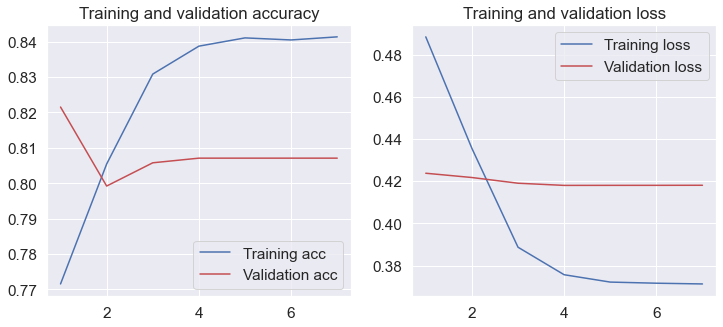

In [33]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(acc) + 1)

    plt.figure(figsize = (12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, acc, 'b', label = 'Training acc')
    plt.plot(x, val_acc, 'r', label = 'Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label = 'Training loss')
    plt.plot(x, val_loss, 'r', label = 'Validation loss')
    plt.title('Training and validation loss')
    plt.legend()
    print("Lowest Validation Loss: epoch {}".format(np.argmin(val_loss)+1))
    print("Highest Validation Accuracy: epoch {}".format(np.argmax(val_acc)+1))

plot_history(history)

Loading the model with the best validation accuracy

In [34]:
def get_min_val_loss_epoch(history):
    return "0" + str(np.argmin(history.history['val_loss'])+1)

def get_max_val_acc_epoch(history):
    return "0" + str(np.argmax(history.history['val_accuracy'])+1)

In [35]:
epoch_num = get_max_val_acc_epoch(history)
model.load_weights(output_dir+"/weights."+epoch_num+".hdf5") # Load in model weights

**Making inference on the test data**

In [36]:
y_test_probs = model.predict(X_val)

# Turn probabilities into an interger prediction
y_hat = []
for prob in y_test_probs:
    y_hat.append(np.argmax(prob))

**Results**

Accuracy: 0.821522309711286


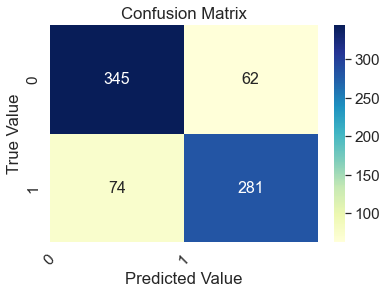

In [37]:
print("Accuracy:", accuracy_score(y_val, y_hat))
print_cf1(y_val, y_hat)

In [39]:
print(classification_report(y_val, y_hat, target_names = ['0', '1']))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       407
           1       0.82      0.79      0.81       355

    accuracy                           0.82       762
   macro avg       0.82      0.82      0.82       762
weighted avg       0.82      0.82      0.82       762



### Looking at which tweets we guessed incorrectly 

Observations that were predicted **Negative** (y_hat = 0) but actually **Positive** (y_test = 2)

*Printing the first 5 examples*

In [40]:
[print(example, '\n') for example in x_val[(y_val == 2) & (np.asarray(y_hat) == 0)][:5]]

[]

Observations that were predicted **Positive** (y_hat = 2) but actually **Negative** (y_test = 0)

*Printing the first 5 examples*

In [41]:
[print(example, '\n') for example in x_val[(y_val == 0) & (np.asarray(y_hat) == 1)][:5]]

Why #Marijuana Is Critical For Research in Treating #PTSD

 
#hempoil #cannabis #marijuanaÛ_  

What happens to us as sexual trauma #survivors defines us as much as we agree with the perpetrators who hurt us. 

Back in Ireland v. sad/traumatised as is freezing and not beautiful Parisian summer to which have become accustomed. 

America like South Africa is a traumatised sick country - in different ways of course - but still messed up. 

A traumatised dog that was found buried up to its head in dirt in France is now in safe hands. This is such a...  



[None, None, None, None, None]

In [43]:
submission_data = pd.read_csv('dataset/sample_submission.csv')

In [44]:
sub_predictions_probability = model.predict(X_test, steps = len(X_test))

In [58]:
submission_data.target = np.asarray([1 if pred[1] > 0.5
                       else 0
                       for pred in sub_predictions_probability])

In [59]:

submission_data

,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1
...,...,...
3258,10861,0
3259,10865,1
3260,10868,1
3261,10874,1


In [60]:
SUBMISSION = 'submissions' 
SUBMISSION = os.path.join('.', SUBMISSION)

In [61]:
from typing import Text, Dict, List, Union, Tuple, Optional, Set
def to_csv(dataframe: pd.DataFrame,
           path: Text,
           file_name: Text,
           with_index: Optional[bool]=False) -> None:
    dataframe.reset_index(drop=True, inplace=True)
    dataframe.to_csv(os.path.join(path, file_name),
                     index=with_index)

In [62]:
if not os.path.isdir(SUBMISSION): os.mkdir(SUBMISSION)
to_csv(submission_data, SUBMISSION, 'submission.csv')